# 03c — 2채널 통계값 추출 RF / XGB (3-Fold CV)

- 입력: V, I 2채널 (TS, WFR 제외)
- 특징: 윈도우(30×2) → 통계 16개 (8 stats × 2ch)
- 탐색: RandomizedSearchCV (3-Fold Stratified, 20 iter)
- 평가: 고정 test set (Val1,2,5,8,9)

In [1]:
from pathlib import Path

BASE_DIR  = Path.home() / 'Desktop' / 'ai1' / 'original_INC_202501'
MODEL_DIR = Path.home() / 'Desktop' / 'ai1' / 'stats2ch_model'
MODEL_DIR.mkdir(exist_ok=True)

FEATURES    = ['Avg Voltage', 'Avg Current']
WINDOW_SIZE = 30
STEP_SIZE   = 10
N_ITER      = 20
RANDOM_SEED = 42

NORMAL_TEST_IDS   = {1,2,3,4,5,7,8,9,10,11,12,28,29,30,44}
ABNORMAL_TEST_IDS = {6,31,45} | set(range(32,44))
NORMAL_VAL_IDS    = set(range(3,10))
ABNORMAL_VAL_IDS  = {1,2}
VAL_TRIAL_IDS     = {44,45}

print('Config OK')

Config OK


In [2]:
import re, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, f1_score,
    precision_score, recall_score
)
import xgboost as xgb

np.random.seed(RANDOM_SEED)
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
print('xgboost:', xgb.__version__)

xgboost: 3.3.0


In [3]:
# 데이터 로드 (V, I / Trial z-score)
def parse_folder_id(name):
    m = re.match(r'^(Test|Val)(\d+)_', name, flags=re.IGNORECASE)
    if not m: return None, None
    return m.group(1).capitalize(), int(m.group(2))

def get_label(prefix, idx):
    if prefix == 'Test':
        if idx in NORMAL_TEST_IDS:   return 0
        if idx in ABNORMAL_TEST_IDS: return 1
    elif prefix == 'Val':
        if idx in NORMAL_VAL_IDS:    return 0
        if idx in ABNORMAL_VAL_IDS:  return 1
    raise ValueError()

def get_split(prefix, idx):
    if prefix == 'Val':          return 'test'
    if idx in VAL_TRIAL_IDS:     return 'val'
    return 'train'

records = []
for d in sorted(BASE_DIR.iterdir()):
    if not d.is_dir(): continue
    prefix, idx = parse_folder_id(d.name)
    if prefix is None: continue
    try:
        label = get_label(prefix, idx)
        split = get_split(prefix, idx)
    except ValueError: continue
    csvs = list(d.glob('*.csv'))
    if not csvs: continue
    data = pd.read_csv(csvs[0])[FEATURES].astype(float).values
    mean, std = data.mean(0), data.std(0)
    std[std < 1e-8] = 1e-8
    records.append({'label': label, 'split': split, 'data': (data - mean) / std})

print(f'Trial 수: {len(records)}')

Trial 수: 19


In [4]:
# 윈도우 생성 + 글로벌 StandardScaler
def make_windows(data, ws, ss):
    return np.stack([data[s:s+ws] for s in range(0, len(data)-ws+1, ss)])

buckets = {'train': ([], []), 'val': ([], []), 'test': ([], [])}
for r in records:
    wins   = make_windows(r['data'], WINDOW_SIZE, STEP_SIZE)
    labels = np.full(len(wins), r['label'], dtype=np.float32)
    buckets[r['split']][0].append(wins)
    buckets[r['split']][1].append(labels)

X_win = {s: np.vstack(buckets[s][0]).astype(np.float32) for s in buckets}
y     = {s: np.concatenate(buckets[s][1]).astype(int)   for s in buckets}

n_feat = X_win['train'].shape[2]  # 2
scaler = StandardScaler()
scaler.fit(X_win['train'].reshape(-1, n_feat))

def scale_win(arr):
    n, w, f = arr.shape
    return scaler.transform(arr.reshape(-1, f)).reshape(n, w, f).astype(np.float32)

Xs = {s: scale_win(X_win[s]) for s in X_win}

for s in ('train', 'val', 'test'):
    u, c = np.unique(y[s], return_counts=True)
    cnt  = dict(zip(u, c))
    print(f'{s:5s}  windows={Xs[s].shape}  normal={cnt.get(0,0):4d}  abnormal={cnt.get(1,0):4d}')

train  windows=(364, 30, 2)  normal= 183  abnormal= 181
val    windows=(58, 30, 2)  normal=  29  abnormal=  29
test   windows=(150, 30, 2)  normal=  95  abnormal=  55


In [5]:
# 통계 특징 추출: 8 stats × 2ch = 16개
STAT_FEAT_NAMES = (
    [f'V_{s}' for s in ['mean','std','min','max','range','median','skew','kurt']] +
    [f'I_{s}' for s in ['mean','std','min','max','range','median','skew','kurt']]
)  # 16개

def extract_stats(X_windows):
    """(N, 30, 2) → (N, 16)"""
    rows = []
    for win in X_windows:
        row = []
        for ch in [0, 1]:  # V, I
            s = win[:, ch]
            row.extend([
                s.mean(), s.std(), s.min(), s.max(),
                s.max() - s.min(),
                float(np.median(s)),
                float(skew(s)),
                float(kurtosis(s)),
            ])
        rows.append(row)
    return np.array(rows, dtype=np.float32)

X_stat = {s: extract_stats(Xs[s]) for s in Xs}

scaler_stat = StandardScaler()
X_stat['train'] = scaler_stat.fit_transform(X_stat['train'])
X_stat['val']   = scaler_stat.transform(X_stat['val'])
X_stat['test']  = scaler_stat.transform(X_stat['test'])

# train+val 합산 (최종 학습용)
X_tv = np.vstack([X_stat['train'], X_stat['val']])
y_tv = np.concatenate([y['train'], y['val']])

print(f'통계 특징: {X_stat["train"].shape[1]}개  → {STAT_FEAT_NAMES}')
print(f'Train+Val: {X_tv.shape}  Test: {X_stat["test"].shape}')

통계 특징: 16개  → ['V_mean', 'V_std', 'V_min', 'V_max', 'V_range', 'V_median', 'V_skew', 'V_kurt', 'I_mean', 'I_std', 'I_min', 'I_max', 'I_range', 'I_median', 'I_skew', 'I_kurt']
Train+Val: (422, 16)  Test: (150, 16)


In [6]:
# RF — RandomizedSearchCV (3-Fold)
rf_param = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
    'class_weight':      ['balanced', None],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED),
    rf_param, n_iter=N_ITER, cv=cv3,
    scoring='roc_auc', refit=True,
    n_jobs=-1, random_state=RANDOM_SEED, verbose=1
)
rf_search.fit(X_tv, y_tv)
rf_model = rf_search.best_estimator_
print(f'RF  best params : {rf_search.best_params_}')
print(f'RF  CV AUC      : {rf_search.best_score_:.4f}')
with open(MODEL_DIR / 'rf_stats2ch.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
RF  best params : {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'class_weight': None}
RF  CV AUC      : 0.9731


In [7]:
# XGB — RandomizedSearchCV (3-Fold)
xgb_param = {
    'n_estimators':  [100, 200, 300, 500],
    'max_depth':     [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample':     [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'scale_pos_weight': [1, 2, 3],
}
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=RANDOM_SEED,
        device='cuda'
    ),
    xgb_param, n_iter=N_ITER, cv=cv3,
    scoring='roc_auc', refit=True,
    n_jobs=-1, random_state=RANDOM_SEED, verbose=1
)
xgb_search.fit(X_tv, y_tv)
xgb_model = xgb_search.best_estimator_
print(f'XGB best params : {xgb_search.best_params_}')
print(f'XGB CV AUC      : {xgb_search.best_score_:.4f}')
with open(MODEL_DIR / 'xgb_stats2ch.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
XGB best params : {'subsample': 0.8, 'scale_pos_weight': 3, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
XGB CV AUC      : 0.9874


In [8]:
# 평가 (test set)
results  = {}
roc_data = {}

def evaluate(name, model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc  = average_precision_score(y_test, y_prob)
    print(f'\n===== {name} (threshold=0.5) =====')
    print(classification_report(y_test, y_pred,
                                target_names=['Normal(0)', 'Abnormal(1)'],
                                zero_division=0))
    print(f'ROC-AUC : {roc_auc:.4f}  |  PR-AUC : {pr_auc:.4f}')
    roc_data[name] = (y_test, y_prob)
    results[name]  = {
        'weighted_f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'macro_f1':    f1_score(y_test, y_pred, average='macro',    zero_division=0),
        'roc_auc': roc_auc, 'pr_auc': pr_auc,
    }

evaluate('RF (2ch stats)',  rf_model,  X_stat['test'], y['test'])
evaluate('XGB (2ch stats)', xgb_model, X_stat['test'], y['test'])


===== RF (2ch stats) (threshold=0.5) =====
              precision    recall  f1-score   support

   Normal(0)       0.66      0.92      0.77        95
 Abnormal(1)       0.58      0.20      0.30        55

    accuracy                           0.65       150
   macro avg       0.62      0.56      0.53       150
weighted avg       0.63      0.65      0.60       150

ROC-AUC : 0.5474  |  PR-AUC : 0.4503

===== XGB (2ch stats) (threshold=0.5) =====
              precision    recall  f1-score   support

   Normal(0)       0.68      0.82      0.75        95
 Abnormal(1)       0.53      0.35      0.42        55

    accuracy                           0.65       150
   macro avg       0.61      0.58      0.58       150
weighted avg       0.63      0.65      0.63       150

ROC-AUC : 0.5876  |  PR-AUC : 0.4618


=== 2채널 통계 특징 (16개) — RF vs XGB ===
          Model  Weighted F1  Macro F1  ROC-AUC  PR-AUC
 RF (2ch stats)        0.597     0.534    0.547   0.450
XGB (2ch stats)        0.626     0.582    0.588   0.462


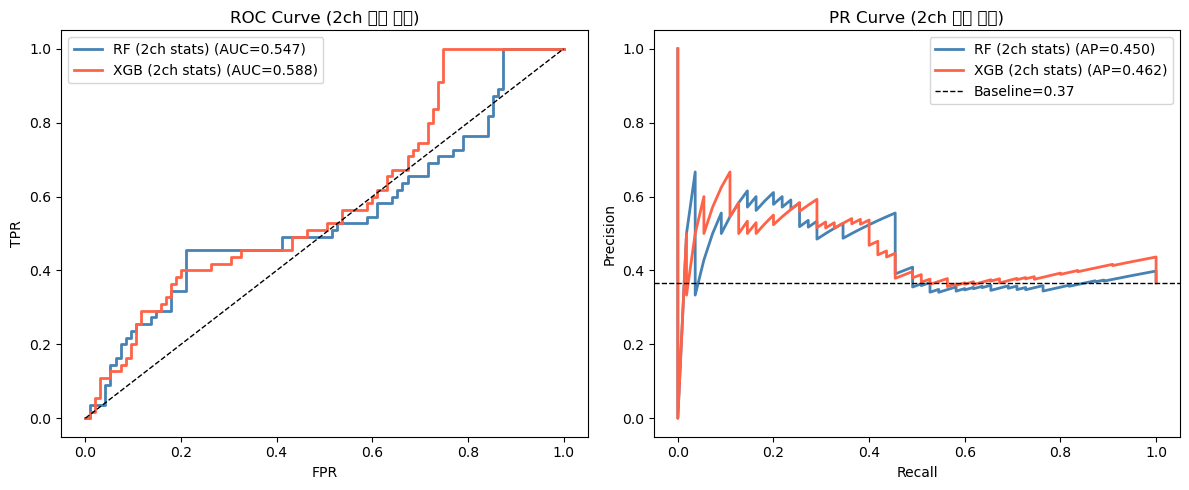

In [9]:
# 비교 요약
df = pd.DataFrame([
    {'Model': k,
     'Weighted F1': round(v['weighted_f1'], 3),
     'Macro F1':    round(v['macro_f1'],    3),
     'ROC-AUC':     round(v['roc_auc'],     3),
     'PR-AUC':      round(v['pr_auc'],      3)}
    for k, v in results.items()
])
print('=== 2채널 통계 특징 (16개) — RF vs XGB ===')
print(df.to_string(index=False))

# ROC 곡선
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['steelblue', 'tomato']
from sklearn.metrics import roc_curve, precision_recall_curve
for (name, (yt, yp)), c in zip(roc_data.items(), colors):
    fpr, tpr, _ = roc_curve(yt, yp)
    axes[0].plot(fpr, tpr, lw=2, color=c,
                 label=f'{name} (AUC={roc_auc_score(yt,yp):.3f})')
    pre, rec, _ = precision_recall_curve(yt, yp)
    axes[1].plot(rec, pre, lw=2, color=c,
                 label=f'{name} (AP={average_precision_score(yt,yp):.3f})')

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve (2ch 통계 특징)'); axes[0].legend()
baseline = y['test'].mean()
axes[1].axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline={baseline:.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve (2ch 통계 특징)'); axes[1].legend()
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'roc_pr_stats2ch.png'), dpi=150)
plt.show()